# Lateral boundary: what happens to a coast-stuck particle?

About 13% of the stuck particles freeze against a **lateral (coastal) wall**
rather than the seafloor. This is the horizontal counterpart of the
`vertical_boundary_investigation`: one particle, in full, to see the mechanism.

Where the vertical case pinned on a **W-face** (`gdepw`, W interpolated
vertically within one column), the horizontal case works through the **C-grid
U,V bilinear interpolation**, which *does* blend across the four faces of a cell.
So the question is what those faces are when a particle reaches the coast.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.path import Path
from scipy.spatial import cKDTree
import matplotlib.pyplot as plt
import config as C

# --- TUNE ME -----------------------------------------------------------------
TID     = 48804           # a coast-stuck particle (None -> pick from the classification)
MONTH_UV = "2005-06"      # a month to read U,V from
# -----------------------------------------------------------------------------

MESHZ = "/work/bk1450/b383184/Amazon/Mercator/data/Zgr_cmesh2.nc"
MESHH = "/work/bk1450/b383184/Amazon/Mercator/data/Hgr_cmesh.nc"
UVW   = "/work/bk1450/b383184/Amazon/Mercator/data/variables_c/UVW"
store_paths = {p.stem: p for p in C.list_stores()}
print("inspecting trajectory:", TID)

inspecting trajectory: 48804


## Grid, mask, and the particle path

In [2]:
Zg = xr.open_dataset(MESHZ); Hg = xr.open_dataset(MESHH)
mbathy = np.asarray(Zg["mbathy"]).squeeze().astype(int)     # 0 = land column
glamf = np.asarray(Hg["glamf"]).squeeze(); gphif = np.asarray(Hg["gphif"]).squeeze()

lab = pd.read_parquet(C.LABELED_FILE,
                      columns=["trajectory_id", "store", "cluster_group", "status"])
if TID is None:
    cl = pd.read_parquet(C.DATA_DIR / "stuck_classification.parquet")
    TID = int(cl[cl.kind.str.startswith("horizontal")].trajectory_id.iloc[0])
st = lab.loc[lab.trajectory_id == TID, "store"].iloc[0]
ds = xr.open_zarr(store_paths[st]); l = TID % C.TRAJ_PER_STORE
m = ~np.isnan(ds.lon.values[l])
lon, lat, z = ds.lon.values[l][m], ds.lat.values[l][m], ds.z.values[l][m]
t = ds.time.values[l][m]; day = (t - t[0]) / np.timedelta64(1, "D")
laf, lof, zf = lat[-1], lon[-1], z[-1]
print(f"particle {TID}: final ({laf:.3f}, {lof:.3f}) depth {zf:.2f} m  "
      f"(a surface, coast-stuck particle)")

particle 48804: final (2.150, -50.792) depth 0.00 m  (a surface, coast-stuck particle)


## Locate it in a grid cell (point-in-quad)

In [3]:
tree = cKDTree(np.c_[glamf.ravel(), gphif.ravel()])
j0, i0 = np.unravel_index(tree.query([lof, laf])[1], glamf.shape)
cell = None
for dj in (-1, 0):
    for di in (-1, 0):
        j, i = j0 + dj, i0 + di
        quad = [(glamf[j, i], gphif[j, i]), (glamf[j, i+1], gphif[j, i+1]),
                (glamf[j+1, i+1], gphif[j+1, i+1]), (glamf[j+1, i], gphif[j+1, i])]
        if Path(quad).contains_point((lof, laf)):
            cell = (j, i); break
    if cell:
        break
j, i = cell
own = int(mbathy[j+1, i+1])
print(f"F-cell (yi,xi) = ({j},{i});  its T-column (yi+1,xi+1) = ({j+1},{i+1})")
print(f"that T-column mbathy = {own}  ->  {'LAND (mbathy=0)' if own==0 else 'wet'}")
print("\nmbathy in a 3x3 around the T-column (0 = land):")
print(mbathy[j:j+3, i:i+3])

F-cell (yi,xi) = (145,530);  its T-column (yi+1,xi+1) = (146,531)
that T-column mbathy = 6  ->  wet

mbathy in a 3x3 around the T-column (0 = land):
[[0 0 0]
 [0 6 6]
 [0 0 6]]


## How Parcels interpolates U and V (the equation)

From the Parcels source (`spatial_c_grid_interpolation2D/3D`, NEMO branch), the
horizontal velocity for a particle in cell `(yi,xi)` reads **four faces** around
the T-column `(yi+1, xi+1)` and blends them bilinearly:

$$U = (1-\xi)\,U[y_i{+}1,\,x_i] + \xi\,U[y_i{+}1,\,x_i{+}1]$$
$$V = (1-\eta)\,V[y_i,\,x_i{+}1] + \eta\,V[y_i{+}1,\,x_i{+}1]$$

- `U` on the **west/east** faces, `V` on the **south/north** faces.
- `ξ, η` are the particle's fractional position in the cell.

Unlike W (single column, no horizontal blend), U,V **do** mix neighbours - so if
some of those faces are on land, the blend is pulled toward zero.


In [4]:
U = xr.open_dataset(f"{UVW}/U_{MONTH_UV}c.nc")["vozocrtx"].isel(
        time_counter=0, deptht=0).values                      # surface
V = xr.open_dataset(f"{UVW}/V_{MONTH_UV}c.nc")["vomecrty"].isel(
        time_counter=0, deptht=0).values

def val(a, y, x):
    v = a[y, x]
    return "NaN -> 0 (land)" if np.isnan(v) else f"{v:+.4f} m/s"

faces = {"U west  U[yi+1,xi]  ": (U, j+1, i),
         "U east  U[yi+1,xi+1]": (U, j+1, i+1),
         "V south V[yi,xi+1]  ": (V, j, i+1),
         "V north V[yi+1,xi+1]": (V, j+1, i+1)}
nland = 0
for name, (a, y, x) in faces.items():
    isl = np.isnan(a[y, x]); nland += isl
    print(f"  {name} = {val(a, y, x)}")
print(f"\n{nland} of 4 velocity faces are land (Parcels sets them to 0 on load).")
print("=> the bilinear blend gives U,V ~ 0, so the particle has no velocity and freezes.")

  U west  U[yi+1,xi]   = NaN -> 0 (land)
  U east  U[yi+1,xi+1] = -0.0105 m/s
  V south V[yi,xi+1]   = NaN -> 0 (land)
  V north V[yi+1,xi+1] = NaN -> 0 (land)

3 of 4 velocity faces are land (Parcels sets them to 0 on load).
=> the bilinear blend gives U,V ~ 0, so the particle has no velocity and freezes.


## The path: it drifts to the coast and stops

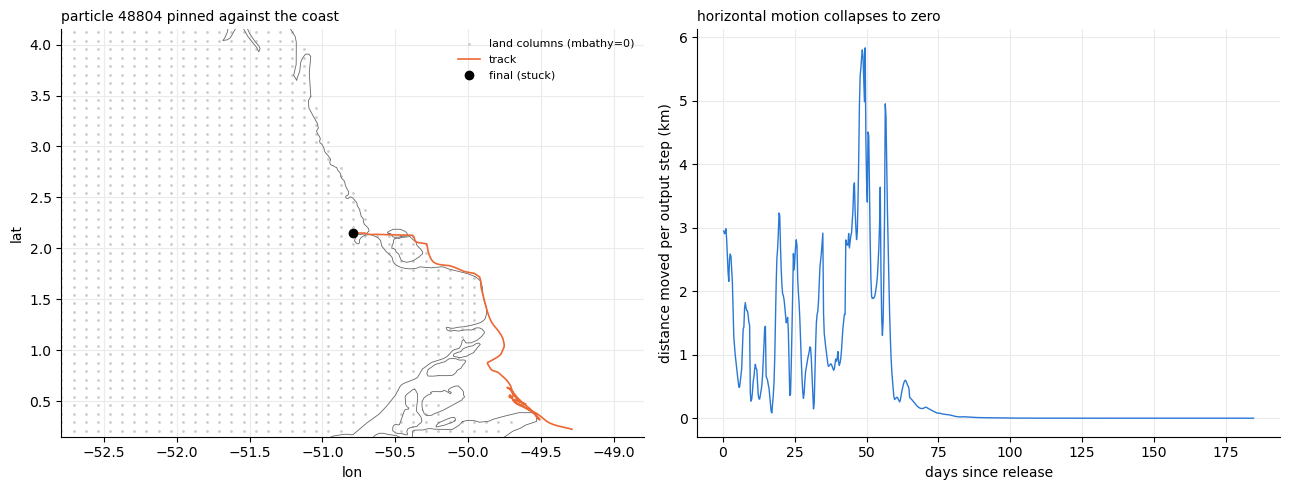

In [5]:
import cartopy.feature as cfeature
_coast = []
for geom in cfeature.COASTLINE.with_scale("10m").geometries():
    for line in getattr(geom, "geoms", [geom]):
        _coast.append((np.asarray(line.xy[0]), np.asarray(line.xy[1])))

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
# map with the land mask + track
LON = (lof - 2, lof + 2); LAT = (laf - 2, laf + 2)
land_j, land_i = np.where(mbathy == 0)
ax[0].scatter(glamf[land_j, land_i], gphif[land_j, land_i], s=1, color="0.8",
              label="land columns (mbathy=0)")
for x, y in _coast:
    ax[0].plot(x, y, "-", color="0.4", lw=.6)
ax[0].plot(lon, lat, "-", color="#eb6834", lw=1.2, label="track")
ax[0].plot(lof, laf, "ko", ms=6, label="final (stuck)")
ax[0].set_xlim(*LON); ax[0].set_ylim(*LAT)
ax[0].set_xlabel("lon"); ax[0].set_ylabel("lat"); ax[0].legend(fontsize=8, frameon=False)
ax[0].set_title(f"particle {TID} pinned against the coast", fontsize=10, loc="left")
# distance-moved per day (freezes -> 0)
step = np.hypot(np.diff(lat), np.diff(lon) * np.cos(np.deg2rad(lat[:-1]))) * 111.32
ax[1].plot(day[1:], step, "-", color="#2a78d6", lw=1)
ax[1].set_xlabel("days since release"); ax[1].set_ylabel("distance moved per output step (km)")
ax[1].set_title("horizontal motion collapses to zero", fontsize=10, loc="left")
for a in ax:
    for s in ("top", "right"): a.spines[s].set_visible(False)
    a.grid(color="0.92"); a.set_axisbelow(True)
fig.tight_layout(); plt.show()

## Are other coast-stuck particles the same?
A quick check that this is the general pattern, not one odd particle.

In [6]:
cl = pd.read_parquet(C.DATA_DIR / "stuck_classification.parquet")
lat_stuck = cl[cl.kind.str.startswith("horizontal")].head(200)
inland = 0
gt = cKDTree(np.c_[glamf.ravel(), gphif.ravel()])
for _, r in lat_stuck.iterrows():
    jj, ii = np.unravel_index(gt.query([r.lon, r.lat])[1], glamf.shape)
    # count land columns in the 3x3 around the nearest T-column
    blk = mbathy[max(jj-1, 0):jj+2, max(ii-1, 0):ii+2]
    if (blk == 0).mean() >= 0.5:
        inland += 1
print(f"of {len(lat_stuck)} lateral-stuck particles, {inland} "
      f"({100*inland/len(lat_stuck):.0f}%) sit where >=half the surrounding "
      f"columns are land - i.e. in/against the coastal mask.")

of 200 lateral-stuck particles, 199 (100%) sit where >=half the surrounding columns are land - i.e. in/against the coastal mask.


## Summary

- The coast-stuck particle ends **inside (or hard against) a land column**
  (`mbathy = 0`). Parcels has zeroed the U,V on the land faces, so the bilinear
  C-grid interpolation returns **U, V ~ 0** - the particle has no velocity in any
  horizontal direction and freezes. It is the exact horizontal twin of the
  seafloor case (`W = 0` on the bottom face), but through the U,V blend instead
  of the single-column W.

- **Same root cause as the vertical boundary:** Parcels replaces every masked
  cell (land, below-seafloor) with 0 on load (`field.py:312`), turning the coast
  into 0-velocity "water." The C-grid interpolation lets a particle drift into
  it, and with no lateral boundary condition it stays.

- This has **nothing to do with `Fix_W`** (that only touches W; here it is U,V),
  and nothing to do with NaN vs 0.0 (Parcels zeros both).

- The cure is the same: a boundary treatment, or - cleaner for publication -
  truncating each trajectory at **coastal contact** (first time it enters a land
  column) in post-processing, so the analysis uses only genuine model advection.

Set `TID = None` to pull another coast-stuck particle.
